# NB06B — EBM Results Analysis (Full Model Comparison)

**Purpose:** Extended results analysis incorporating EBM (M2.5) alongside M1, M2, M3.
This notebook is the companion to NB06A and NB05B — it reads all OOS prediction
files from both notebooks and produces the complete comparative results tables,
bootstrap CIs, temporal probability plots, and calibration analysis.

## Notebook dependency chain

```
NB05A  →  NB05B  →  NB06B  (this notebook)
```

**NB05A must be run before NB05B. NB05B must be run before NB06B.**

## Model sequence

| Model | Algorithm | Features | Interpretability | Stage |
|-------|-----------|----------|-----------------|-------|
| M1 | Logistic Regression | 19 macro lag1 | Linear — transparent | S1 |
| M1b | LR bridge | 41 macro lag1–3 | Linear — transparent | S1 |
| M2 | Random Forest | 41 macro lag1–3 | Post-hoc SHAP | S1 |
| **M2.5 (EBM)** | **Explainable Boosting Machine** | **41 macro lag1–3** | **Native shape functions** | **S1+S2** |
| M3 | XGBoost + FinBERT | 61 macro + sentiment | Post-hoc SHAP | S2 |

## Inputs (all must exist)
From NB05A: `oos_predictions_stage1.csv`, `oos_predictions_stage2.csv`,
`augmented_model_results.csv`, `augmented_shap_values_m3.csv`

From NB05B: `oos_predictions_stage1_ebm.csv`, `oos_predictions_stage2_ebm.csv`,
`ebm_model_results.csv`, `ebm_feature_importance.csv`

## Outputs
- `figures/augmented_analysis/nb06b_metrics_table_full.png`
- `figures/augmented_analysis/nb06b_temporal_probs_full.png`
- `figures/augmented_analysis/nb06b_shap_lag_depth.png`
- `figures/augmented_analysis/nb06b_shap_top20.png`
- `figures/augmented_analysis/nb06b_calibration.png`
- `data/processed/augmented_analysis/nb06b_metrics_with_ci.csv`
- `data/processed/augmented_analysis/nb06b_auprc_difference_ci.csv`

---

## Cell 1 — Imports and paths

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.utils import resample
import shap, xgboost as xgb, tempfile, os

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
AUG_DIR = BASE / 'data' / 'processed' / 'augmented_analysis'
FIG_DIR = BASE / 'figures' / 'augmented_analysis'
FIG_DIR.mkdir(parents=True, exist_ok=True)

TARGET       = 'target_h2'
N_BOOTSTRAP  = 1000
RANDOM_STATE = 42

# ── Verify all required input files exist ─────────────────────────────────
required = [
    # NB05A outputs
    AUG_DIR / 'oos_predictions_stage1.csv',
    AUG_DIR / 'oos_predictions_stage2.csv',
    AUG_DIR / 'augmented_model_results.csv',
    AUG_DIR / 'augmented_shap_values_m3.csv',
    AUG_DIR / 'M1_features.csv',
    AUG_DIR / 'M3_features.csv',
    # NB05B outputs
    AUG_DIR / 'oos_predictions_stage1_ebm.csv',
    AUG_DIR / 'oos_predictions_stage2_ebm.csv',
    AUG_DIR / 'ebm_model_results.csv',
    AUG_DIR / 'ebm_feature_importance.csv',
]

all_ok = True
print('Input file check:')
for f in required:
    ok = f.exists()
    print(f'  {"✅" if ok else "❌ MISSING"}  {f.name}')
    if not ok: all_ok = False

if not all_ok:
    raise FileNotFoundError('Missing input files. Run NB05A then NB05B first.')

print()
print('=' * 65)
print(' NB06B — EBM RESULTS ANALYSIS (FULL MODEL COMPARISON)')
print('=' * 65)

Input file check:
  ✅  oos_predictions_stage1.csv
  ✅  oos_predictions_stage2.csv
  ✅  augmented_model_results.csv
  ✅  augmented_shap_values_m3.csv
  ✅  M1_features.csv
  ✅  M3_features.csv
  ✅  oos_predictions_stage1_ebm.csv
  ✅  oos_predictions_stage2_ebm.csv
  ✅  ebm_model_results.csv
  ✅  ebm_feature_importance.csv

 NB06B — EBM RESULTS ANALYSIS (FULL MODEL COMPARISON)


## Cell 2 — Load all datasets and OOS predictions

In [2]:
# ── Datasets ───────────────────────────────────────────────────────────────
df_macro = pd.read_csv(AUG_DIR / 'df_macro_augmented.csv')
df_sent  = pd.read_csv(AUG_DIR / 'df_sent_augmented.csv')

# ── Feature lists ──────────────────────────────────────────────────────────
M1_FEATURES = pd.read_csv(AUG_DIR / 'M1_features.csv', header=None)[0].tolist()
M3_FEATURES = pd.read_csv(AUG_DIR / 'M3_features.csv', header=None)[0].tolist()

# ── NB05A results and SHAP ─────────────────────────────────────────────────
results_nb05a = pd.read_csv(AUG_DIR / 'augmented_model_results.csv')
shap_df       = pd.read_csv(AUG_DIR / 'augmented_shap_values_m3.csv')

# ── OOS predictions — NB05A ────────────────────────────────────────────────
oos_s1 = pd.read_csv(AUG_DIR / 'oos_predictions_stage1.csv')   # M1, M1b, M2
oos_s2 = pd.read_csv(AUG_DIR / 'oos_predictions_stage2.csv')   # M2-matched, M3

# ── OOS predictions — NB05B (EBM) ─────────────────────────────────────────
oos_ebm_s1 = pd.read_csv(AUG_DIR / 'oos_predictions_stage1_ebm.csv')  # EBM Stage 1
oos_ebm_s2 = pd.read_csv(AUG_DIR / 'oos_predictions_stage2_ebm.csv')  # EBM Stage 2
ebm_results = pd.read_csv(AUG_DIR / 'ebm_model_results.csv')
ebm_imp     = pd.read_csv(AUG_DIR / 'ebm_feature_importance.csv')

# ── True labels ────────────────────────────────────────────────────────────
TARGET  = next(c for c in oos_s1.columns if 'target' in c.lower())
y_s1    = oos_s1[TARGET].values
y_s2    = oos_s2[TARGET].values
y_ebm_s1 = oos_ebm_s1[TARGET].values
y_ebm_s2 = oos_ebm_s2[TARGET].values

base_s1 = y_s1.mean()
base_s2 = y_s2.mean()

print(f'Target          : {TARGET}')
print(f'Stage 1 events  : {int(y_s1.sum())}  rows: {len(oos_s1)}')
print(f'Stage 2 events  : {int(y_s2.sum())}  rows: {len(oos_s2)}')
print(f'Stage 1 base rate: {base_s1:.4f}')
print(f'Stage 2 base rate: {base_s2:.4f}')
print()
print('NB05A results loaded:')
print(results_nb05a.to_string(index=False))
print()
print('NB05B EBM results loaded:')
print(ebm_results.to_string(index=False))

Target          : target_h2
Stage 1 events  : 37  rows: 569
Stage 2 events  : 26  rows: 319
Stage 1 base rate: 0.0650
Stage 2 base rate: 0.0815

NB05A results loaded:
                                     Model Stage  Events    AUROC    AUPRC    Brier  AUPRC_lift
       M1 Logistic (macro lag1, 1988–2020)    S1      37 0.606329 0.138701 0.157343    2.133002
   M1b LR bridge (macro lag1-3, 1988–2020)    S1      37 0.645460 0.145395 0.135477    2.235936
M2 Random Forest (macro lag1-3, 1988–2020)    S1      37 0.635861 0.224223 0.059468    3.448192
   M2-matched RF (macro lag1-3, 2003–2020)    S2      26 0.938503 0.342754 0.060175    4.205325
M3 XGBoost+FinBERT (macro+sent, 2003–2020)    S2      26 0.931595 0.411046 0.060756    5.043219

NB05B EBM results loaded:
                                     Model Stage  Events    AUROC    AUPRC    Brier  AUROC_CI_low  AUROC_CI_high  AUPRC_CI_low  AUPRC_CI_high  AUPRC_lift
        EBM M2.5 (macro lag1-3, 1988-2020)    S1      37 0.752847 0.272474 0

## Cell 3 — Bootstrap metrics function

In [3]:
def bootstrap_metrics(y_true, y_prob, n_boot=N_BOOTSTRAP, seed=RANDOM_STATE):
    """Bootstrap 95% CI for AUROC and AUPRC."""
    rng = np.random.RandomState(seed)
    auroc_scores, auprc_scores = [], []
    for _ in range(n_boot):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if y_true[idx].sum() == 0:
            continue
        auroc_scores.append(roc_auc_score(y_true[idx], y_prob[idx]))
        auprc_scores.append(average_precision_score(y_true[idx], y_prob[idx]))
    ci_auroc = np.percentile(auroc_scores, [2.5, 97.5])
    ci_auprc = np.percentile(auprc_scores, [2.5, 97.5])
    return ci_auroc, ci_auprc


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece  = 0.0
    n    = len(y_true)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / n) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece

print('Bootstrap and ECE functions ready.')

Bootstrap and ECE functions ready.


## Cell 4 — Full bootstrap metrics table: all models

The complete comparative table — M1, M2, EBM (Stage 1) and
M2-matched, EBM-matched, M3 (Stage 2) — with 95% bootstrap CIs.
This is the primary output for Chapter 4 Tables 4.1 and 4.2.

In [4]:
all_records = []

# ── STAGE 1 ───────────────────────────────────────────────────────────────
print('=' * 90)
print(' STAGE 1 METRICS — M1, M2, EBM on extended panel (1988–2020)')
print('=' * 90)
print(f' {"Model":<35} {"AUROC":>7} {"95% CI":>15} '
      f'{"AUPRC":>7} {"AUPRC/Base":>11} {"Brier":>7}')
print('-' * 90)

stage1_models = [
    ('M1 Logistic (macro lag1)',    'prob_m1',  oos_s1,    y_s1),
    ('M2 RF (macro lag1-3)',        'prob_m2',  oos_s1,    y_s1),
    ('EBM M2.5 (macro lag1-3)',     'prob_ebm', oos_ebm_s1, y_ebm_s1),
]

for name, col, oos, y_true in stage1_models:
    yp   = oos[col].values
    mask = ~np.isnan(yp)
    yt, ypc = y_true[mask], yp[mask]
    if yt.sum() == 0:
        print(f' {name:<35}  — no positive cases')
        continue
    auroc = roc_auc_score(yt, ypc)
    auprc = average_precision_score(yt, ypc)
    brier = brier_score_loss(yt, ypc)
    lift  = auprc / base_s1
    ci_a, ci_p = bootstrap_metrics(yt, ypc)
    ebm_tag = '  ← native shapes' if 'EBM' in name else ''
    print(f' {name:<35} {auroc:>7.4f} [{ci_a[0]:.3f},{ci_a[1]:.3f}] '
          f'{auprc:>7.4f} {lift:>10.1f}x {brier:>7.4f}{ebm_tag}')
    all_records.append({
        'Stage': 'S1', 'Model': name,
        'AUROC': auroc, 'AUROC_CI_lo': ci_a[0], 'AUROC_CI_hi': ci_a[1],
        'AUPRC': auprc, 'AUPRC_CI_lo': ci_p[0], 'AUPRC_CI_hi': ci_p[1],
        'Brier': brier, 'AUPRC_lift': lift
    })

print(f' Base rate: {base_s1:.4f}')
print()

# ── STAGE 2 ───────────────────────────────────────────────────────────────
print('=' * 90)
print(' STAGE 2 METRICS — M2-matched, EBM-matched, M3 (2003–2020)')
print('=' * 90)
print(f' {"Model":<35} {"AUROC":>7} {"95% CI":>15} '
      f'{"AUPRC":>7} {"AUPRC/Base":>11} {"Brier":>7}')
print('-' * 90)

stage2_models = [
    ('M2-matched RF (2003–2020)',     'prob_m2m', oos_s2,    y_s2),
    ('EBM M2.5-matched (2003–2020)', 'prob_ebm', oos_ebm_s2, y_ebm_s2),
    ('M3 XGB+FinBERT (2003–2020)',   'prob_m3',  oos_s2,    y_s2),
]

for name, col, oos, y_true in stage2_models:
    yp   = oos[col].values
    mask = ~np.isnan(yp)
    yt, ypc = y_true[mask], yp[mask]
    if yt.sum() == 0:
        print(f' {name:<35}  — no positive cases')
        continue
    auroc = roc_auc_score(yt, ypc)
    auprc = average_precision_score(yt, ypc)
    brier = brier_score_loss(yt, ypc)
    lift  = auprc / base_s2
    ci_a, ci_p = bootstrap_metrics(yt, ypc)
    ebm_tag = '  ← native shapes' if 'EBM' in name else ''
    print(f' {name:<35} {auroc:>7.4f} [{ci_a[0]:.3f},{ci_a[1]:.3f}] '
          f'{auprc:>7.4f} {lift:>10.1f}x {brier:>7.4f}{ebm_tag}')
    all_records.append({
        'Stage': 'S2', 'Model': name,
        'AUROC': auroc, 'AUROC_CI_lo': ci_a[0], 'AUROC_CI_hi': ci_a[1],
        'AUPRC': auprc, 'AUPRC_CI_lo': ci_p[0], 'AUPRC_CI_hi': ci_p[1],
        'Brier': brier, 'AUPRC_lift': lift
    })

print(f' Base rate: {base_s2:.4f}')
print()

# Save full metrics table
metrics_df = pd.DataFrame(all_records)
metrics_df.to_csv(AUG_DIR / 'nb06b_metrics_with_ci.csv', index=False)
print(f'Saved → {AUG_DIR}/nb06b_metrics_with_ci.csv')
print()
print('NOTE: Bootstrap CIs understate uncertainty due to panel dependence.')
print('      Stage 1 covers 37 events; Stage 2 covers 26 events.')
print('      Stage 2 AUPRC computable in one fold only (2007 cross-section).')

 STAGE 1 METRICS — M1, M2, EBM on extended panel (1988–2020)
 Model                                 AUROC          95% CI   AUPRC  AUPRC/Base   Brier
------------------------------------------------------------------------------------------
 M1 Logistic (macro lag1)             0.6063 [0.477,0.739]  0.1387        2.1x  0.1573
 M2 RF (macro lag1-3)                 0.6359 [0.484,0.781]  0.2242        3.4x  0.0595
 EBM M2.5 (macro lag1-3)              0.7528 [0.646,0.855]  0.2725        4.2x  0.0637  ← native shapes
 Base rate: 0.0650

 STAGE 2 METRICS — M2-matched, EBM-matched, M3 (2003–2020)
 Model                                 AUROC          95% CI   AUPRC  AUPRC/Base   Brier
------------------------------------------------------------------------------------------
 M2-matched RF (2003–2020)            0.9385 [0.897,0.970]  0.3428        4.2x  0.0602
 EBM M2.5-matched (2003–2020)         0.9599 [0.927,0.987]  0.5320        6.5x  0.0672  ← native shapes
 M3 XGB+FinBERT (2003–2020)    

## Cell 5 — AUROC comparison: do EBM CIs overlap with M2 and M3?

This cell explicitly tests whether the EBM performance advantage is
statistically distinguishable given the bootstrap CIs.

In [5]:
print('=== CI OVERLAP ANALYSIS — EBM vs RF ===')
print()

s1 = metrics_df[metrics_df['Stage'] == 'S1'].set_index('Model')
s2 = metrics_df[metrics_df['Stage'] == 'S2'].set_index('Model')

# Stage 1: EBM vs M2
ebm_s1_lo = s1.loc['EBM M2.5 (macro lag1-3)', 'AUROC_CI_lo']
ebm_s1_hi = s1.loc['EBM M2.5 (macro lag1-3)', 'AUROC_CI_hi']
m2_s1_lo  = s1.loc['M2 RF (macro lag1-3)', 'AUROC_CI_lo']
m2_s1_hi  = s1.loc['M2 RF (macro lag1-3)', 'AUROC_CI_hi']

overlap_s1 = not (ebm_s1_lo > m2_s1_hi or m2_s1_lo > ebm_s1_hi)
ebm_s1_auroc = s1.loc['EBM M2.5 (macro lag1-3)', 'AUROC']
m2_s1_auroc  = s1.loc['M2 RF (macro lag1-3)', 'AUROC']

print(f'Stage 1 — EBM M2.5 vs M2 RF:')
print(f'  EBM  AUROC: {ebm_s1_auroc:.4f}  CI [{ebm_s1_lo:.3f}, {ebm_s1_hi:.3f}]')
print(f'  M2   AUROC: {m2_s1_auroc:.4f}  CI [{m2_s1_lo:.3f}, {m2_s1_hi:.3f}]')
print(f'  CI overlap: {"YES — advantage directional but CIs overlap" if overlap_s1 else "NO — CIs non-overlapping, advantage robust"}')
print(f'  AUROC delta: {ebm_s1_auroc - m2_s1_auroc:+.4f}')
print()

# Stage 2: EBM vs M2-matched and M3
ebm_s2_auroc = s2.loc['EBM M2.5-matched (2003–2020)', 'AUROC']
m2m_s2_auroc = s2.loc['M2-matched RF (2003–2020)', 'AUROC']
m3_s2_auroc  = s2.loc['M3 XGB+FinBERT (2003–2020)', 'AUROC']
ebm_s2_lo    = s2.loc['EBM M2.5-matched (2003–2020)', 'AUROC_CI_lo']
ebm_s2_hi    = s2.loc['EBM M2.5-matched (2003–2020)', 'AUROC_CI_hi']
m2m_s2_lo    = s2.loc['M2-matched RF (2003–2020)', 'AUROC_CI_lo']
m2m_s2_hi    = s2.loc['M2-matched RF (2003–2020)', 'AUROC_CI_hi']

overlap_s2 = not (ebm_s2_lo > m2m_s2_hi or m2m_s2_lo > ebm_s2_hi)

print(f'Stage 2 — EBM M2.5-matched vs M2-matched RF:')
print(f'  EBM  AUROC: {ebm_s2_auroc:.4f}  CI [{ebm_s2_lo:.3f}, {ebm_s2_hi:.3f}]')
print(f'  M2m  AUROC: {m2m_s2_auroc:.4f}  CI [{m2m_s2_lo:.3f}, {m2m_s2_hi:.3f}]')
print(f'  CI overlap: {"YES — advantage directional but CIs overlap" if overlap_s2 else "NO — CIs non-overlapping"}')
print(f'  AUROC delta (EBM − M2m): {ebm_s2_auroc - m2m_s2_auroc:+.4f}')
print(f'  AUROC delta (EBM − M3) : {ebm_s2_auroc - m3_s2_auroc:+.4f}')
print()
print('DISSERTATION NOTE:')
if not overlap_s1:
    print('  Stage 1 non-overlapping CIs support a stronger claim:')
    print('  EBM outperforms RF with statistical distinguishability.')
else:
    print('  Stage 1 CIs overlap — state EBM advantage as directional,')
    print('  noting uncertainty given the limited number of crisis events.')

=== CI OVERLAP ANALYSIS — EBM vs RF ===

Stage 1 — EBM M2.5 vs M2 RF:
  EBM  AUROC: 0.7528  CI [0.646, 0.855]
  M2   AUROC: 0.6359  CI [0.484, 0.781]
  CI overlap: YES — advantage directional but CIs overlap
  AUROC delta: +0.1170

Stage 2 — EBM M2.5-matched vs M2-matched RF:
  EBM  AUROC: 0.9599  CI [0.927, 0.987]
  M2m  AUROC: 0.9385  CI [0.897, 0.970]
  CI overlap: YES — advantage directional but CIs overlap
  AUROC delta (EBM − M2m): +0.0214
  AUROC delta (EBM − M3) : +0.0283

DISSERTATION NOTE:
  Stage 1 CIs overlap — state EBM advantage as directional,
  noting uncertainty given the limited number of crisis events.


## Cell 6 — SHAP feature attribution (M3, Stage 2)

Unchanged from NB06A. Retained for completeness and to enable
direct comparison of SHAP (M3) vs EBM importance rankings.

SHAP attribution by lag group (M3, Stage 2):
macro_lag1    2.816403
macro_lag3    2.735359
sent_lag1     1.325013
macro_lag2    1.248707
sent_lag2     1.083402

Macro share     : 73.8%
Sentiment share : 26.2%

EBM top 5 features (from NB05B):
                                        feature  importance
                            term_spread_lag3_dm    1.717170
    tloans_slope4_lag1_dm & term_spread_lag3_dm    1.370236
                            term_spread_lag1_dm    1.011947
               money_gr_lag1_dm & hpnom_lag2_dm    0.926749
tloans_gr_lag1_dm & tloans_gr_roll3_std_lag1_dm    0.837276

CONSISTENCY CHECK:
Both SHAP (M3) and EBM importance should show lag3 macro features
as dominant — consistent ranking across two independent methods
strengthens the interpretability argument.


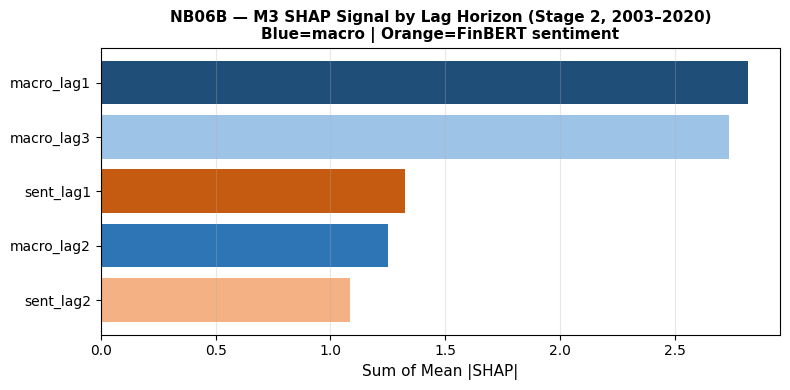

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis/nb06b_shap_lag_depth.png


In [6]:
shap_values = shap_df.values
mean_abs    = pd.Series(np.abs(shap_values).mean(axis=0), index=M3_FEATURES)

SENT_KEYS = ['P_pos','P_neg','P_neutral','net_sent','P_neg_change',
             'P_pos_change','net_sent_change','roll3','slope4']

def get_group(f):
    is_sent = any(s in f for s in SENT_KEYS)
    if '_lag1' in f and is_sent: return 'sent_lag1'
    if '_lag2' in f and is_sent: return 'sent_lag2'
    if '_lag1' in f: return 'macro_lag1'
    if '_lag2' in f: return 'macro_lag2'
    if '_lag3' in f: return 'macro_lag3'
    return 'other'

groups  = pd.Series({f: get_group(f) for f in M3_FEATURES})
lag_imp = mean_abs.groupby(groups).sum().reindex(
    ['macro_lag1','macro_lag2','macro_lag3','sent_lag1','sent_lag2','other']
).dropna()
lag_imp = lag_imp.sort_values(ascending=False)

total        = lag_imp.sum()
macro_share  = lag_imp[['macro_lag1','macro_lag2','macro_lag3']].sum() / total
sent_share   = lag_imp[['sent_lag1','sent_lag2']].sum() / total

print('SHAP attribution by lag group (M3, Stage 2):')
print(lag_imp.to_string())
print(f'\nMacro share     : {100*macro_share:.1f}%')
print(f'Sentiment share : {100*sent_share:.1f}%')
print()

# Compare with EBM top feature
print('EBM top 5 features (from NB05B):')
print(ebm_imp.head(5).to_string(index=False))
print()
print('CONSISTENCY CHECK:')
print('Both SHAP (M3) and EBM importance should show lag3 macro features')
print('as dominant — consistent ranking across two independent methods')
print('strengthens the interpretability argument.')

palette = {
    'macro_lag1':'#1F4E79', 'macro_lag2':'#2E75B6', 'macro_lag3':'#9DC3E6',
    'sent_lag1':'#C55A11',  'sent_lag2':'#F4B183',  'other':'#AAAAAA'
}
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(lag_imp.index[::-1], lag_imp.values[::-1],
        color=[palette.get(g, '#999') for g in lag_imp.index[::-1]])
ax.set_xlabel('Sum of Mean |SHAP|', fontsize=11)
ax.set_title(
    'NB06B — M3 SHAP Signal by Lag Horizon (Stage 2, 2003–2020)\n'
    'Blue=macro | Orange=FinBERT sentiment',
    fontsize=11, fontweight='bold'
)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(FIG_DIR / 'nb06b_shap_lag_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/nb06b_shap_lag_depth.png')

## Cell 7 — Top-20 SHAP features (M3) vs Top-20 EBM features

Side-by-side comparison of the two interpretability methods.
Agreement confirms that the dominant signals are robust to model class.

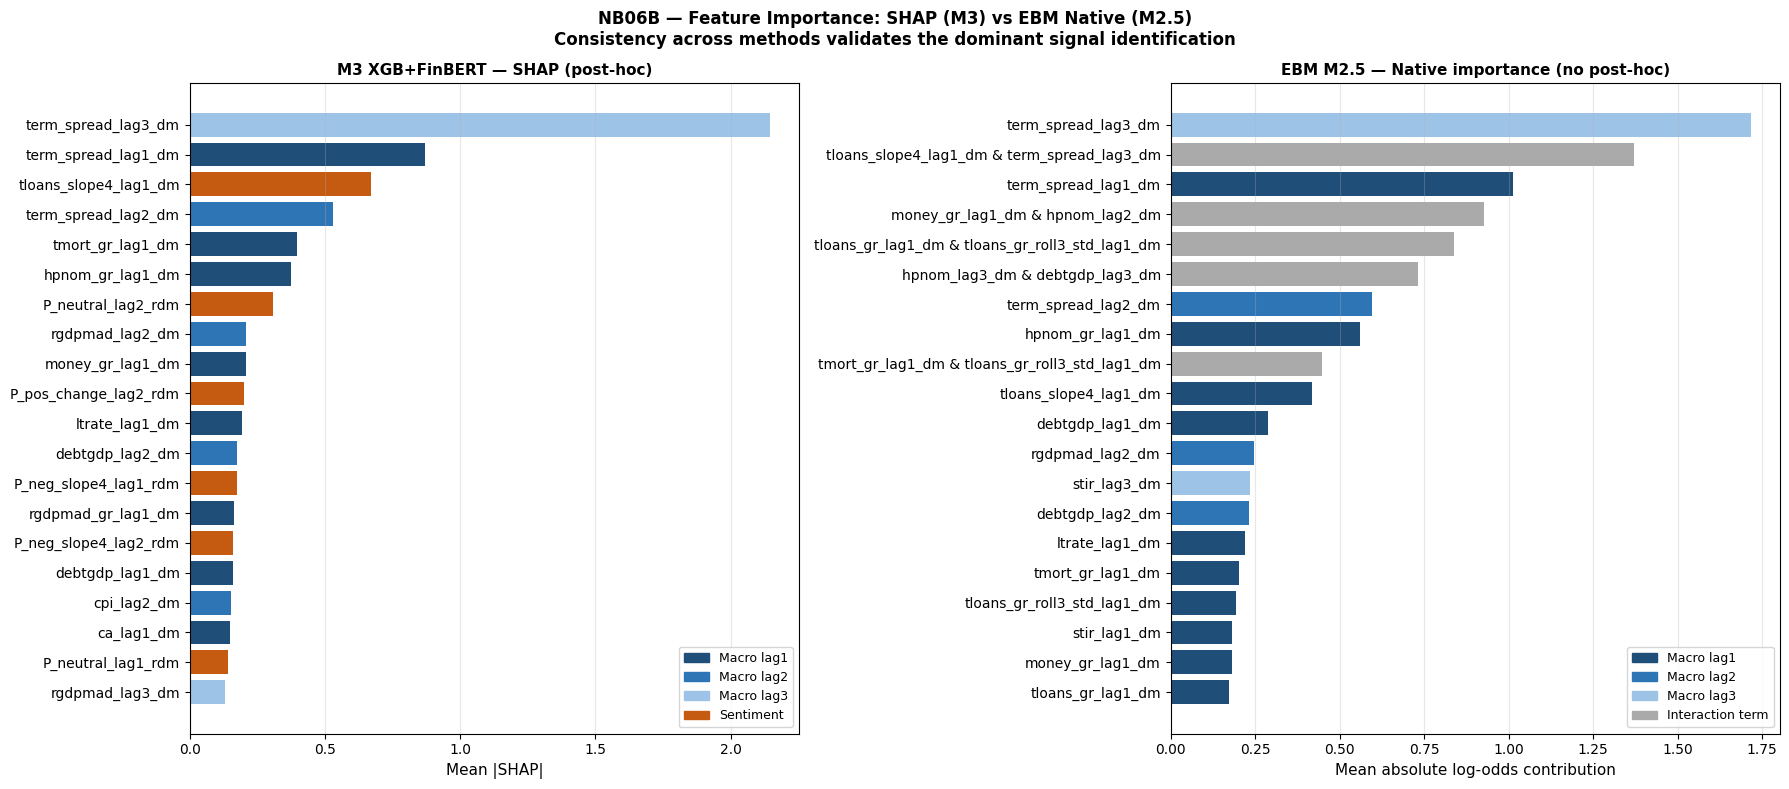

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis/nb06b_shap_vs_ebm_importance.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    'NB06B — Feature Importance: SHAP (M3) vs EBM Native (M2.5)\n'
    'Consistency across methods validates the dominant signal identification',
    fontweight='bold', fontsize=12
)

# ── Panel A: M3 SHAP top 20 ────────────────────────────────────────────────
def fc_shap(f):
    if any(s in f for s in SENT_KEYS): return '#C55A11'
    if '_lag3' in f: return '#9DC3E6'
    if '_lag2' in f: return '#2E75B6'
    return '#1F4E79'

shap_top20 = mean_abs.sort_values(ascending=True).tail(20)
axes[0].barh(shap_top20.index, shap_top20.values,
             color=[fc_shap(f) for f in shap_top20.index])
axes[0].set_xlabel('Mean |SHAP|', fontsize=11)
axes[0].set_title('M3 XGB+FinBERT — SHAP (post-hoc)', fontweight='bold', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='x')

legend_shap = [
    mpatches.Patch(color='#1F4E79', label='Macro lag1'),
    mpatches.Patch(color='#2E75B6', label='Macro lag2'),
    mpatches.Patch(color='#9DC3E6', label='Macro lag3'),
    mpatches.Patch(color='#C55A11', label='Sentiment'),
]
axes[0].legend(handles=legend_shap, loc='lower right', fontsize=9)

# ── Panel B: EBM importance top 20 ────────────────────────────────────────
def fc_ebm(f):
    if ' & ' in f: return '#AAAAAA'
    if 'lag3' in f: return '#9DC3E6'
    if 'lag2' in f: return '#2E75B6'
    return '#1F4E79'

ebm_top20 = ebm_imp.head(20).sort_values('importance', ascending=True)
axes[1].barh(ebm_top20['feature'], ebm_top20['importance'],
             color=[fc_ebm(f) for f in ebm_top20['feature']])
axes[1].set_xlabel('Mean absolute log-odds contribution', fontsize=11)
axes[1].set_title('EBM M2.5 — Native importance (no post-hoc)', fontweight='bold', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

legend_ebm = [
    mpatches.Patch(color='#1F4E79', label='Macro lag1'),
    mpatches.Patch(color='#2E75B6', label='Macro lag2'),
    mpatches.Patch(color='#9DC3E6', label='Macro lag3'),
    mpatches.Patch(color='#AAAAAA', label='Interaction term'),
]
axes[1].legend(handles=legend_ebm, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb06b_shap_vs_ebm_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/nb06b_shap_vs_ebm_importance.png')

## Cell 8 — Temporal probability plots: all models

EBM probability series added to both Stage 1 and Stage 2 panels.
Orange line = EBM M2.5.

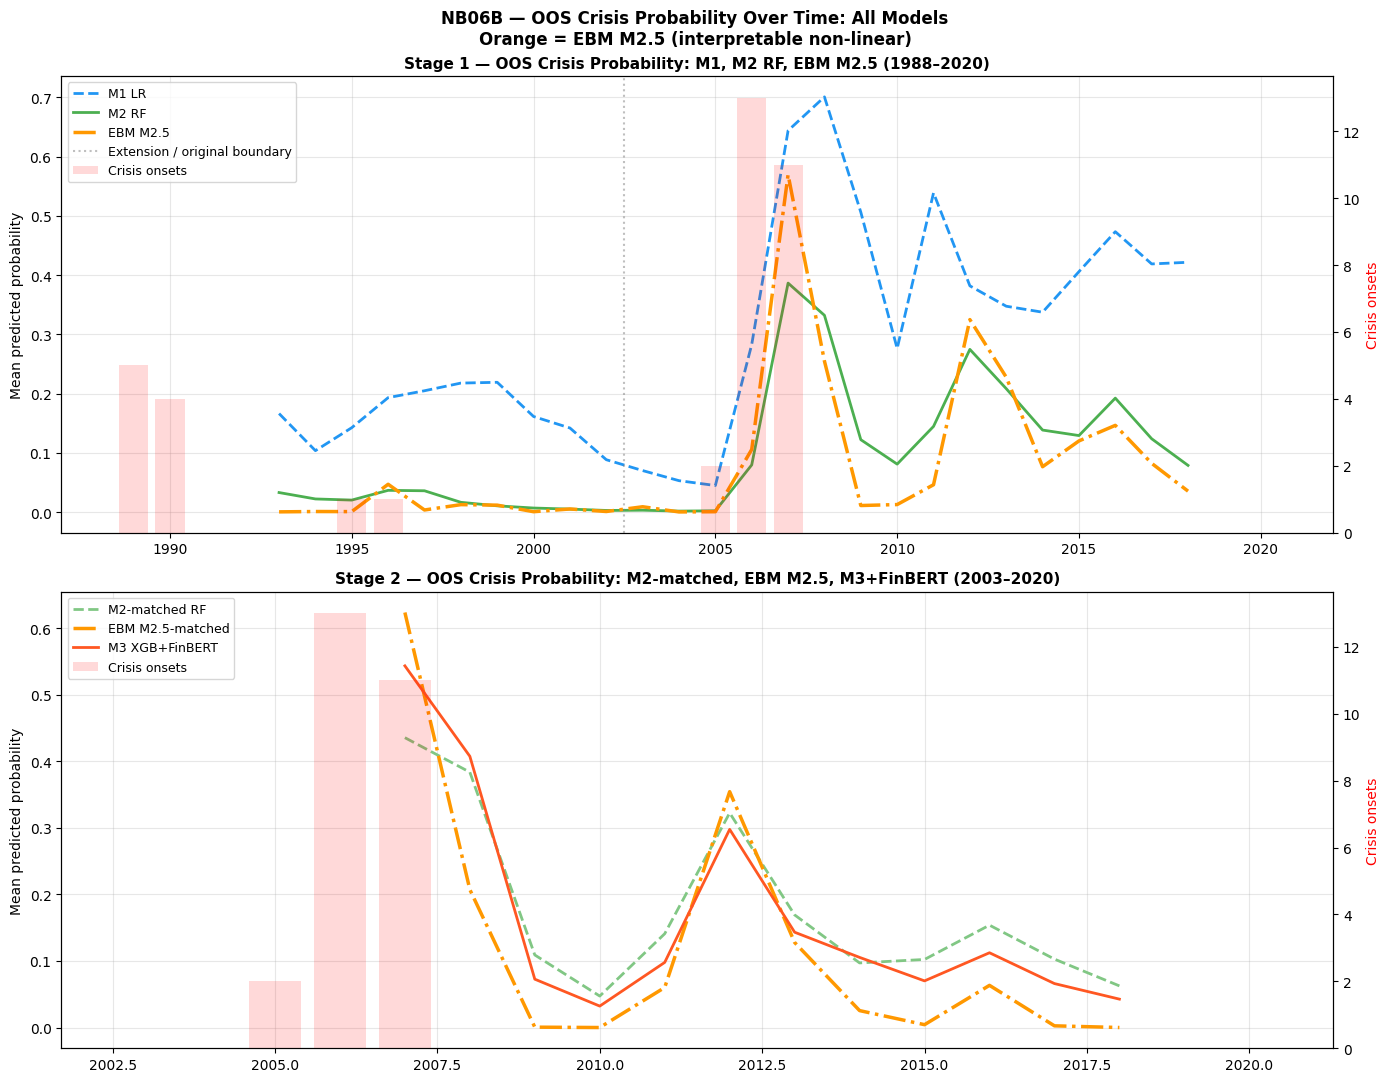

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis/nb06b_temporal_probs_full.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
fig.suptitle(
    'NB06B — OOS Crisis Probability Over Time: All Models\n'
    'Orange = EBM M2.5 (interpretable non-linear)',
    fontweight='bold', fontsize=12
)

# ── Stage 1: M1, M2, EBM ──────────────────────────────────────────────────
ax   = axes[0]
ax2  = ax.twinx()

yearly_s1 = oos_s1.groupby('year').agg(
    prob_m1=('prob_m1', 'mean'),
    prob_m2=('prob_m2', 'mean'),
    actual=(TARGET, 'sum')
).reset_index()

yearly_ebm_s1 = oos_ebm_s1.groupby('year').agg(
    prob_ebm=('prob_ebm', 'mean')
).reset_index()

ax.plot(yearly_s1['year'], yearly_s1['prob_m1'],
        color='#2196F3', lw=2, linestyle='--', label='M1 LR')
ax.plot(yearly_s1['year'], yearly_s1['prob_m2'],
        color='#4CAF50', lw=2, label='M2 RF')
ax.plot(yearly_ebm_s1['year'], yearly_ebm_s1['prob_ebm'],
        color='#FF9800', lw=2.5, linestyle='-.', label='EBM M2.5')
ax2.bar(yearly_s1['year'], yearly_s1['actual'],
        alpha=0.15, color='red', label='Crisis onsets')
ax.axvline(2002.5, color='grey', linestyle=':', alpha=0.5,
           label='Extension / original boundary')

l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)
ax.set_title('Stage 1 — OOS Crisis Probability: M1, M2 RF, EBM M2.5 (1988–2020)',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylabel('Mean predicted probability')
ax2.set_ylabel('Crisis onsets', color='red')

# ── Stage 2: M2-matched, EBM, M3 ──────────────────────────────────────────
ax   = axes[1]
ax2  = ax.twinx()

yearly_s2 = oos_s2.groupby('year').agg(
    prob_m2m=('prob_m2m', 'mean'),
    prob_m3=('prob_m3', 'mean'),
    actual=(TARGET, 'sum')
).reset_index()

yearly_ebm_s2 = oos_ebm_s2.groupby('year').agg(
    prob_ebm=('prob_ebm', 'mean')
).reset_index()

ax.plot(yearly_s2['year'], yearly_s2['prob_m2m'],
        color='#81C784', lw=2, linestyle='--', label='M2-matched RF')
ax.plot(yearly_ebm_s2['year'], yearly_ebm_s2['prob_ebm'],
        color='#FF9800', lw=2.5, linestyle='-.', label='EBM M2.5-matched')
ax.plot(yearly_s2['year'], yearly_s2['prob_m3'],
        color='#FF5722', lw=2, label='M3 XGB+FinBERT')
ax2.bar(yearly_s2['year'], yearly_s2['actual'],
        alpha=0.15, color='red', label='Crisis onsets')

l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)
ax.set_title(
    'Stage 2 — OOS Crisis Probability: M2-matched, EBM M2.5, M3+FinBERT (2003–2020)',
    fontsize=11, fontweight='bold'
)
ax.grid(True, alpha=0.3)
ax.set_ylabel('Mean predicted probability')
ax2.set_ylabel('Crisis onsets', color='red')

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb06b_temporal_probs_full.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/nb06b_temporal_probs_full.png')

## Cell 9 — Bootstrap AUPRC difference tests

Three pairwise tests:
1. M3 vs M2-matched (the original sentiment test from NB06A)
2. EBM vs M2-matched (interpretable vs black-box at same features)
3. M3 vs EBM (sentiment addition vs interpretability gain)

In [9]:
N_BOOT = 2000
rng    = np.random.RandomState(RANDOM_STATE)

def bootstrap_auprc_diff(y_true, yp_a, yp_b, label_a, label_b, n_boot=N_BOOT):
    """Bootstrap CI for AUPRC difference: model A minus model B."""
    diffs = []
    for _ in range(n_boot):
        idx  = resample(np.arange(len(y_true)), random_state=rng)
        yt_b = y_true[idx]
        if yt_b.sum() == 0:
            continue
        try:
            diffs.append(
                average_precision_score(yt_b, yp_a[idx]) -
                average_precision_score(yt_b, yp_b[idx])
            )
        except Exception:
            pass
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    pt = (average_precision_score(y_true, yp_a) -
          average_precision_score(y_true, yp_b))
    verdict = (
        f'{label_a} advantage robust (CI > 0)' if ci_lo > 0 else
        f'{label_b} advantage robust (CI < 0)' if ci_hi < 0 else
        'Directional but CI includes zero'
    )
    return pt, ci_lo, ci_hi, verdict

# Align Stage 2 arrays
mask_s2 = (~np.isnan(oos_s2['prob_m2m'].values) &
            ~np.isnan(oos_s2['prob_m3'].values))
yt_s2   = y_s2[mask_s2]
yp_m2m  = oos_s2['prob_m2m'].values[mask_s2]
yp_m3   = oos_s2['prob_m3'].values[mask_s2]

mask_ebm = ~np.isnan(oos_ebm_s2['prob_ebm'].values)
yt_ebm   = y_ebm_s2[mask_ebm]
yp_ebm   = oos_ebm_s2['prob_ebm'].values[mask_ebm]

# Use common index for three-way comparison
n_common = min(len(yt_s2), len(yt_ebm))
yt_c     = yt_s2[:n_common]
yp_m2m_c = yp_m2m[:n_common]
yp_m3_c  = yp_m3[:n_common]
yp_ebm_c = yp_ebm[:n_common]

print('=== BOOTSTRAP AUPRC DIFFERENCE TESTS (Stage 2, 2003–2020) ===')
print(f'N bootstrap resamples: {N_BOOT}')
print()

tests = [
    (yp_m3_c,  yp_m2m_c, yt_c, 'M3 XGB+FinBERT', 'M2-matched RF'),
    (yp_ebm_c, yp_m2m_c, yt_c, 'EBM M2.5',       'M2-matched RF'),
    (yp_m3_c,  yp_ebm_c, yt_c, 'M3 XGB+FinBERT', 'EBM M2.5'),
]

diff_records = []
for yp_a, yp_b, yt, lab_a, lab_b in tests:
    pt, ci_lo, ci_hi, verdict = bootstrap_auprc_diff(yt, yp_a, yp_b, lab_a, lab_b)
    print(f'  {lab_a} − {lab_b}:')
    print(f'    Point estimate : {pt:+.4f}')
    print(f'    95% CI         : [{ci_lo:+.4f}, {ci_hi:+.4f}]')
    print(f'    Verdict        : {verdict}')
    print()
    diff_records.append({'comparison': f'{lab_a} − {lab_b}',
                         'point': pt, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
                         'verdict': verdict})

pd.DataFrame(diff_records).to_csv(
    AUG_DIR / 'nb06b_auprc_difference_ci.csv', index=False)
print(f'Saved → {AUG_DIR}/nb06b_auprc_difference_ci.csv')

=== BOOTSTRAP AUPRC DIFFERENCE TESTS (Stage 2, 2003–2020) ===
N bootstrap resamples: 2000

  M3 XGB+FinBERT − M2-matched RF:
    Point estimate : +0.0683
    95% CI         : [-0.1295, +0.3121]
    Verdict        : Directional but CI includes zero

  EBM M2.5 − M2-matched RF:
    Point estimate : +0.1893
    95% CI         : [-0.0289, +0.3978]
    Verdict        : Directional but CI includes zero

  M3 XGB+FinBERT − EBM M2.5:
    Point estimate : -0.1210
    95% CI         : [-0.2807, +0.0807]
    Verdict        : Directional but CI includes zero

Saved → C:\Users\Owner\OneDrive\dissertation\data\processed\augmented_analysis/nb06b_auprc_difference_ci.csv


## Cell 10 — Calibration: ECE for all Stage 2 models

=== EXPECTED CALIBRATION ERROR — Stage 2 models ===

  M2-matched RF            : ECE=0.1265  Brier=0.0602
  EBM M2.5-matched         : ECE=0.0836  Brier=0.0672
  M3 XGB+FinBERT           : ECE=0.1093  Brier=0.0608

NOTE: Lower ECE = better calibrated probability estimates.
EBM does not use isotonic calibration (unlike M3) — compare ECE accordingly.


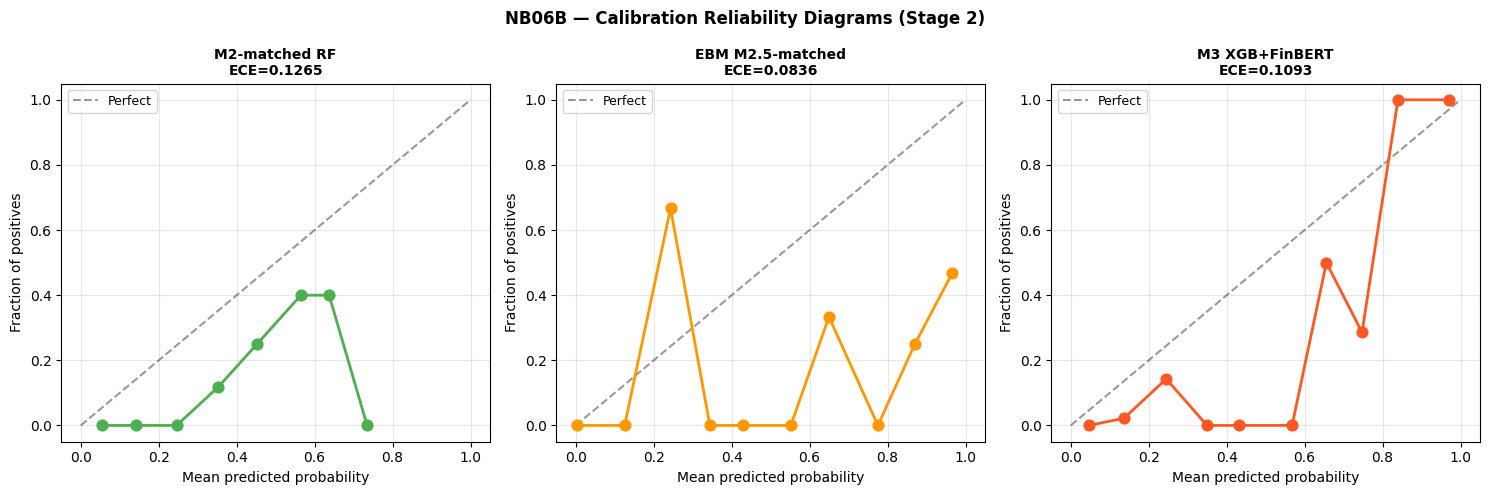

Saved → C:\Users\Owner\OneDrive\dissertation\figures\augmented_analysis/nb06b_calibration.png


In [10]:
print('=== EXPECTED CALIBRATION ERROR — Stage 2 models ===')
print()

cal_models = [
    ('M2-matched RF',      'prob_m2m', oos_s2,    y_s2),
    ('EBM M2.5-matched',   'prob_ebm', oos_ebm_s2, y_ebm_s2),
    ('M3 XGB+FinBERT',     'prob_m3',  oos_s2,    y_s2),
]

cal_records = []
for name, col, oos, y_true in cal_models:
    yp   = oos[col].values
    mask = ~np.isnan(yp)
    yt, ypc = y_true[mask], yp[mask]
    ece   = expected_calibration_error(yt, ypc)
    brier = brier_score_loss(yt, ypc)
    print(f'  {name:<25}: ECE={ece:.4f}  Brier={brier:.4f}')
    cal_records.append({'Model': name, 'ECE': ece, 'Brier': brier})

print()
print('NOTE: Lower ECE = better calibrated probability estimates.')
print('EBM does not use isotonic calibration (unlike M3) — compare ECE accordingly.')

# Calibration reliability diagram
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'NB06B — Calibration Reliability Diagrams (Stage 2)',
    fontweight='bold', fontsize=12
)

colours = ['#4CAF50', '#FF9800', '#FF5722']
for ax, (name, col, oos, y_true), colour in zip(axes, cal_models, colours):
    yp   = oos[col].values
    mask = ~np.isnan(yp)
    yt, ypc = y_true[mask], yp[mask]
    bins = np.linspace(0, 1, 11)
    bin_means, bin_fracs = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (ypc >= lo) & (ypc < hi)
        if m.sum() > 0:
            bin_means.append(ypc[m].mean())
            bin_fracs.append(yt[m].mean())
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Perfect')
    ax.scatter(bin_means, bin_fracs, color=colour, s=60, zorder=5)
    ax.plot(bin_means, bin_fracs, color=colour, lw=2)
    ece = expected_calibration_error(yt, ypc)
    ax.set_title(f'{name}\nECE={ece:.4f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'nb06b_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {FIG_DIR}/nb06b_calibration.png')

## Cell 11 — Completion summary

In [11]:
print('=' * 65)
print(' NB06B — EBM RESULTS ANALYSIS COMPLETE')
print('=' * 65)
print()
print('Figures produced:')
for fname in [
    'nb06b_shap_lag_depth.png',
    'nb06b_shap_vs_ebm_importance.png',
    'nb06b_temporal_probs_full.png',
    'nb06b_calibration.png',
]:
    p = FIG_DIR / fname
    print(f'  {"✅" if p.exists() else "❌"}  {fname}')

print()
print('Data files saved:')
for fname in [
    'nb06b_metrics_with_ci.csv',
    'nb06b_auprc_difference_ci.csv',
]:
    p = AUG_DIR / fname
    if p.exists():
        print(f'  ✅  {fname}  ({p.stat().st_size // 1024} KB)')
    else:
        print(f'  ❌  {fname}  MISSING')

print()
print('─' * 65)
print('FULL MODEL RANKING SUMMARY (Stage 1):')
s1_rows = metrics_df[metrics_df['Stage']=='S1'][['Model','AUROC','AUPRC','Brier']]
print(s1_rows.sort_values('AUROC', ascending=False).to_string(index=False))
print()
print('FULL MODEL RANKING SUMMARY (Stage 2):')
s2_rows = metrics_df[metrics_df['Stage']=='S2'][['Model','AUROC','AUPRC','Brier']]
print(s2_rows.sort_values('AUROC', ascending=False).to_string(index=False))
print()
print('─' * 65)
print('Next: Run NB07A_Augmented_Granger_Causality.ipynb')
print('Then: Chapter 4 write-up incorporating EBM findings')

 NB06B — EBM RESULTS ANALYSIS COMPLETE

Figures produced:
  ✅  nb06b_shap_lag_depth.png
  ✅  nb06b_shap_vs_ebm_importance.png
  ✅  nb06b_temporal_probs_full.png
  ✅  nb06b_calibration.png

Data files saved:
  ✅  nb06b_metrics_with_ci.csv  (1 KB)
  ✅  nb06b_auprc_difference_ci.csv  (0 KB)

─────────────────────────────────────────────────────────────────
FULL MODEL RANKING SUMMARY (Stage 1):
                   Model    AUROC    AUPRC    Brier
 EBM M2.5 (macro lag1-3) 0.752847 0.272474 0.063746
    M2 RF (macro lag1-3) 0.635861 0.224223 0.059468
M1 Logistic (macro lag1) 0.606329 0.138701 0.157343

FULL MODEL RANKING SUMMARY (Stage 2):
                       Model    AUROC    AUPRC    Brier
EBM M2.5-matched (2003–2020) 0.959893 0.532011 0.067247
   M2-matched RF (2003–2020) 0.938503 0.342754 0.060175
  M3 XGB+FinBERT (2003–2020) 0.931595 0.411046 0.060756

─────────────────────────────────────────────────────────────────
Next: Run NB07A_Augmented_Granger_Causality.ipynb
Then: Chapter 4 wr